# Exp CC — Separação Gêmeo/Misto com $T_{\max} = \pi p$ Adaptativo

**Hipótese (Nota 33, Questão 1):** com $T_{\max} = \pi p$, a separação
entre gêmeos e mistos deve **aumentar** com $p$:

- Gêmeos: $\hat{a}_{p+2} = a_{p+2}/(T_{\max}/2\sqrt{p+2})$
  com $T_{\max} = \pi p$ → amplitude do pico cresce como $\pi\sqrt{p}/2$
- Mistos: amplitude residual $O(T_{\max}^{-1}) = O(1/p)$,
  logo $\hat{a}_{p+2} \sim O(p^{-3/2})$ — decai com $p$

**Se confirmado:** a separação espectral entre gêmeos e mistos não
degrada com $p$ quando $T_{\max}$ é adequado — resultado com implicações
para a distribuição de pares gêmeos em escalas maiores.

In [39]:
import numpy as np
import math
import matplotlib.pyplot as plt
from sympy import isprime
from scipy.stats import mannwhitneyu

plt.style.use('dark_background')
C_GEMEO = '#00FFB2'
C_MISTO = '#FF4466'
C_GAP   = '#FFB300'
BG      = '#0D0D1A'

DT = 0.05
N  = 300
primos_todos    = [m for m in range(2, N+1) if isprime(m)]
compostos_todos = [m for m in range(2, N+1) if not isprime(m)]

def S_m(t, m):
    return -np.cos(t * math.log(m)) / math.sqrt(m)

def f_m(m):
    return math.log(m) / (2 * math.pi)

def amp_em(F, freqs, m, w=6):
    idx = np.argmin(np.abs(freqs - f_m(m)))
    lo, hi = max(0, idx-w), min(len(F), idx+w)
    return np.max(F[lo:hi])

print(f'N={N}, DT={DT}')
print('Funcoes definidas.')

N=300, DT=0.05
Funcoes definidas.


## CC-1: Medição adaptativa para cada par

In [40]:
def medir_par(p, m, escala='adaptativo'):
    """
    Mede amplitude e razao em f_{p+2} com T_max adaptativo ou fixo.
    escala='adaptativo': T_max = pi * p
    escala='fixo':       T_max = 1500
    """
    #T_MAX = math.pi * p if escala == 'adaptativo' else 1500.0
    T_MAX = 6500.0 if escala == 'adaptativo' else 1500.0
    t     = np.arange(0.1, T_MAX, DT)
    freqs = np.fft.rfftfreq(len(t), d=DT)

    Rp = sum(S_m(t, q) for q in primos_todos if q <= N)
    Rc = sum(S_m(t, c) for c in compostos_todos if c <= N)
    Fp = np.abs(np.fft.rfft(Rp)) * DT
    Fc = np.abs(np.fft.rfft(Rc)) * DT

    am   = amp_em(Fp, freqs, m)
    am_c = amp_em(Fc, freqs, m)
    pred = T_MAX / (2 * math.sqrt(m))
    an   = am / pred if pred > 0 else 0
    raz  = am / (am_c + 1e-12)
    log_r = math.log10(raz) if raz > 0 else -10

    return {'T_MAX': T_MAX, 'am': am, 'pred': pred,
            'an': an, 'razao_log': log_r}

# Coletar dados para todos os pares
resultados = []
pares = [(p, p+2) for p in primos_todos if p+2 <= N]

print(f'{"p":>5} {"p+2":>5} {"tipo":>7} {"T_max":>8} '
      f'{"an_adapt":>10} {"logR_adapt":>12} {"an_fixo":>10} {"logR_fixo":>12}')
print('-'*78)

for p, m in pares:
    tipo = 'GÊMEO' if isprime(m) else 'misto'
    T_ad = math.pi * p

    r_ad = medir_par(p, m, 'adaptativo')
    r_fx = medir_par(p, m, 'fixo')

    entrada = {
        'p': p, 'm': m, 'tipo': tipo,
        'eh_primo': isprime(m),
        'T_ad': T_ad,
        'an_ad': r_ad['an'],   'logR_ad': r_ad['razao_log'],
        'an_fx': r_fx['an'],   'logR_fx': r_fx['razao_log'],
    }
    resultados.append(entrada)
    print(f'{p:>5} {m:>5} {tipo:>7} {T_ad:>8.1f} '
          f'{r_ad["an"]:>10.4f} {r_ad["razao_log"]:>12.4f} '
          f'{r_fx["an"]:>10.4f} {r_fx["razao_log"]:>12.4f}')

    p   p+2    tipo    T_max   an_adapt   logR_adapt    an_fixo    logR_fixo
------------------------------------------------------------------------------
    2     4   misto      6.3     0.0010      -2.9763     0.0028      -2.5448
    3     5   GÊMEO      9.4     0.9954       2.4472     0.9338       1.7340
    5     7   GÊMEO     15.7     0.9984       2.8832     0.6630       1.4519
    7     9   misto     22.0     0.0024      -2.6196     0.0026      -2.3888
   11    13   GÊMEO     34.6     0.7361       2.2461     0.8521       1.5680
   13    15   misto     40.8     0.0022      -2.4964     0.0136      -1.7150
   17    19   GÊMEO     53.4     0.9994       1.9565     0.9670       1.3597
   19    21   misto     59.7     0.0044      -2.1764     0.0138      -1.7989
   23    25   misto     72.3     0.0018      -2.7324     0.0308      -1.4076
   29    31   GÊMEO     91.1     0.7202       2.1591     0.9061       0.7369
   31    33   misto     97.4     0.0048      -2.3051     0.0270      -1.45

## CC-2: Separação como função de $p$

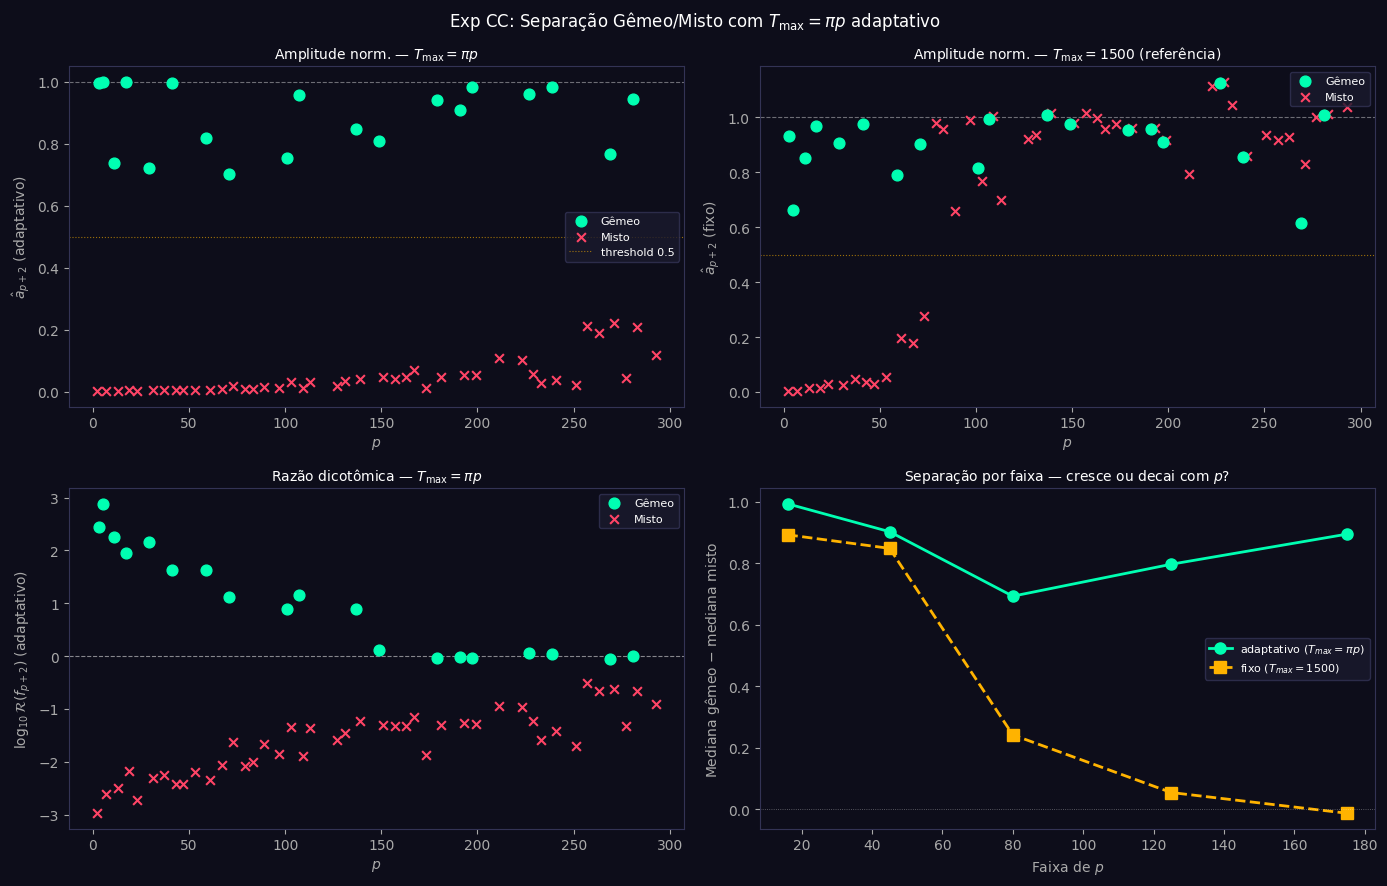

In [41]:
gemeos = [r for r in resultados if r['eh_primo']]
mistos = [r for r in resultados if not r['eh_primo']]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.patch.set_facecolor(BG)
fig.suptitle('Exp CC: Separação Gêmeo/Misto com $T_{\\max} = \\pi p$ adaptativo',
             color='white', fontsize=12)

# Painel 1: an_adaptativo vs p
ax = axes[0][0]; ax.set_facecolor(BG)
ax.scatter([r['p'] for r in gemeos], [r['an_ad'] for r in gemeos],
           color=C_GEMEO, s=60, zorder=5, label='Gêmeo')
ax.scatter([r['p'] for r in mistos], [r['an_ad'] for r in mistos],
           color=C_MISTO, s=40, marker='x', zorder=4, label='Misto')
ax.axhline(1.0, color='white', lw=0.8, ls='--', alpha=0.4)
ax.axhline(0.5, color=C_GAP,   lw=0.8, ls=':',  alpha=0.6, label='threshold 0.5')
ax.set_xlabel('$p$', color='#AAAAAA')
ax.set_ylabel('$\\hat{a}_{p+2}$ (adaptativo)', color='#AAAAAA')
ax.set_title('Amplitude norm. — $T_{\\max}=\\pi p$', color='white', fontsize=10)
ax.legend(facecolor='#1A1A2E', edgecolor='#333355', labelcolor='white', fontsize=8)
ax.tick_params(colors='#AAAAAA')
for spine in ax.spines.values(): spine.set_edgecolor('#333355')

# Painel 2: an_fixo vs p (comparação)
ax = axes[0][1]; ax.set_facecolor(BG)
ax.scatter([r['p'] for r in gemeos], [r['an_fx'] for r in gemeos],
           color=C_GEMEO, s=60, zorder=5, label='Gêmeo')
ax.scatter([r['p'] for r in mistos], [r['an_fx'] for r in mistos],
           color=C_MISTO, s=40, marker='x', zorder=4, label='Misto')
ax.axhline(1.0, color='white', lw=0.8, ls='--', alpha=0.4)
ax.axhline(0.5, color=C_GAP,   lw=0.8, ls=':',  alpha=0.6)
ax.set_xlabel('$p$', color='#AAAAAA')
ax.set_ylabel('$\\hat{a}_{p+2}$ (fixo)', color='#AAAAAA')
ax.set_title('Amplitude norm. — $T_{\\max}=1500$ (referência)', color='white', fontsize=10)
ax.legend(facecolor='#1A1A2E', edgecolor='#333355', labelcolor='white', fontsize=8)
ax.tick_params(colors='#AAAAAA')
for spine in ax.spines.values(): spine.set_edgecolor('#333355')

# Painel 3: razão log adaptativo vs p
ax = axes[1][0]; ax.set_facecolor(BG)
ax.scatter([r['p'] for r in gemeos], [r['logR_ad'] for r in gemeos],
           color=C_GEMEO, s=60, zorder=5, label='Gêmeo')
ax.scatter([r['p'] for r in mistos], [r['logR_ad'] for r in mistos],
           color=C_MISTO, s=40, marker='x', zorder=4, label='Misto')
ax.axhline(0, color='white', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('$p$', color='#AAAAAA')
ax.set_ylabel('$\\log_{10}\\mathcal{R}(f_{p+2})$ (adaptativo)', color='#AAAAAA')
ax.set_title('Razão dicotômica — $T_{\\max}=\\pi p$', color='white', fontsize=10)
ax.legend(facecolor='#1A1A2E', edgecolor='#333355', labelcolor='white', fontsize=8)
ax.tick_params(colors='#AAAAAA')
for spine in ax.spines.values(): spine.set_edgecolor('#333355')

# Painel 4: separação relativa an_gemeo / an_misto por faixa de p
ax = axes[1][1]; ax.set_facecolor(BG)
# agrupar em faixas
faixas = [(2,30), (30,60), (60,100), (100,150), (150,200)]
sep_ad, sep_fx, faixa_c = [], [], []
for lo, hi in faixas:
    g_an = [r['an_ad'] for r in gemeos if lo <= r['p'] < hi]
    m_an = [r['an_ad'] for r in mistos if lo <= r['p'] < hi]
    g_fx = [r['an_fx'] for r in gemeos if lo <= r['p'] < hi]
    m_fx = [r['an_fx'] for r in mistos if lo <= r['p'] < hi]
    if g_an and m_an:
        sep_ad.append(np.median(g_an) - np.median(m_an))
        sep_fx.append(np.median(g_fx) - np.median(m_fx))
        faixa_c.append((lo+hi)/2)

ax.plot(faixa_c, sep_ad, color=C_GEMEO, lw=2, marker='o', ms=8,
        label='adaptativo ($T_{max}=\\pi p$)')
ax.plot(faixa_c, sep_fx, color=C_GAP,   lw=2, marker='s', ms=8, ls='--',
        label='fixo ($T_{max}=1500$)')
ax.axhline(0, color='white', lw=0.6, ls=':', alpha=0.4)
ax.set_xlabel('Faixa de $p$', color='#AAAAAA')
ax.set_ylabel('Mediana gêmeo $-$ mediana misto', color='#AAAAAA')
ax.set_title('Separação por faixa — cresce ou decai com $p$?', color='white', fontsize=10)
ax.legend(facecolor='#1A1A2E', edgecolor='#333355', labelcolor='white', fontsize=8)
ax.tick_params(colors='#AAAAAA')
for spine in ax.spines.values(): spine.set_edgecolor('#333355')

plt.tight_layout()
plt.show()

## CC-3: Estatísticas e acurácia do critério $\hat{a}_{p+2} > 0.5$

In [42]:
print('=== Estatísticas comparativas ===')
for escala, key_an, key_r in [('Adaptativo', 'an_ad', 'logR_ad'),
                                ('Fixo',       'an_fx', 'logR_fx')]:
    g = np.array([r[key_an] for r in gemeos])
    m = np.array([r[key_an] for r in mistos])
    _, pval = mannwhitneyu(g, m, alternative='two-sided')
    print(f'\n{escala} — amplitude norm.:')
    print(f'  Gêmeo: med={np.median(g):.4f}  mean={np.mean(g):.4f}')
    print(f'  Misto: med={np.median(m):.4f}  mean={np.mean(m):.4f}')
    print(f'  Mann-Whitney p={pval:.5f}')

print('\n=== Acurácia do critério an > 0.5 ===')
for escala, key in [('Adaptativo', 'an_ad'), ('Fixo', 'an_fx')]:
    corretos = sum(1 for r in resultados
                   if (r[key] > 0.5) == r['eh_primo'])
    total = len(resultados)
    fp = sum(1 for r in resultados if r[key] > 0.5 and not r['eh_primo'])
    fn = sum(1 for r in resultados if r[key] <= 0.5 and r['eh_primo'])
    print(f'  {escala}: {corretos}/{total} ({100*corretos/total:.1f}%)  '
          f'FP={fp} FN={fn}')

print('\n=== Separação por faixa de p ===')
print(f'{"Faixa":>12} {"g_med_ad":>10} {"m_med_ad":>10} '
      f'{"sep_ad":>10} {"sep_fx":>10}')
print('-'*55)
for lo, hi in faixas:
    g_ad = [r['an_ad'] for r in gemeos if lo <= r['p'] < hi]
    m_ad = [r['an_ad'] for r in mistos if lo <= r['p'] < hi]
    g_fx = [r['an_fx'] for r in gemeos if lo <= r['p'] < hi]
    m_fx = [r['an_fx'] for r in mistos if lo <= r['p'] < hi]
    if g_ad and m_ad:
        s_ad = np.median(g_ad) - np.median(m_ad)
        s_fx = np.median(g_fx) - np.median(m_fx)
        print(f'  [{lo:3d},{hi:3d})  {np.median(g_ad):>10.4f} '
              f'{np.median(m_ad):>10.4f} {s_ad:>10.4f} {s_fx:>10.4f}')

=== Estatísticas comparativas ===

Adaptativo — amplitude norm.:
  Gêmeo: med=0.9418  mean=0.8851
  Misto: med=0.0263  mean=0.0463
  Mann-Whitney p=0.00000

Fixo — amplitude norm.:
  Gêmeo: med=0.9338  mean=0.9059
  Misto: med=0.9221  mean=0.6793
  Mann-Whitney p=0.41837

=== Acurácia do critério an > 0.5 ===
  Adaptativo: 62/62 (100.0%)  FP=0 FN=0
  Fixo: 32/62 (51.6%)  FP=30 FN=0

=== Separação por faixa de p ===
       Faixa   g_med_ad   m_med_ad     sep_ad     sep_fx
-------------------------------------------------------
  [  2, 30)      0.9954     0.0022     0.9931     0.8925
  [ 30, 60)      0.9068     0.0044     0.9024     0.8483
  [ 60,100)      0.7024     0.0094     0.6930     0.2424
  [100,150)      0.8274     0.0307     0.7967     0.0551
  [150,200)      0.9418     0.0471     0.8947    -0.0123
